In [40]:
import numpy as np
import polars as pl
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 16

# 2.A : Few trajectories + Mean + Theory (Homogeneous)

In [47]:
# --- Load files --- #
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-12__PC/nucleo__fig2_0")
paths = [str(p) for p in root.glob("*/**/*.parquet")] or [str(p) for p in root.glob("*/*.parquet")]
df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algorithm", "fact", "factmode",
        "landscape", "s", "l", "lmbda", "alphar"
        ])
)

df_one = df_all.filter(pl.col("landscape") == "homogeneous")
thetas = np.unique(df_one["theta"].to_numpy())


# --- Figure --- #
for idx, theta_val in enumerate(thetas[:]):

    # --- Data ---
    df_theta = df_one.filter(pl.col("theta") == theta_val)
    trajs = df_theta["results"][0].to_numpy()
    mean_traj = df_theta["results_mean"][0].to_numpy()
    v_mean_th = df_theta["v_mean_th"].to_numpy()
    times = df_theta["times"][0].to_numpy()
    mu = df_theta["mu"].to_numpy()

    # --- Figure ---
    plt.figure(figsize=(8,6), dpi=1200)

    # Trajectoires individuelles
    plt.plot(trajs[0], drawstyle="steps-post",
             color="red", alpha=0.30, label="Trajectories")
    for i in range(1, 10):
        plt.plot(trajs[i], drawstyle="steps-post",
                 color="red", alpha=0.30)

    # Moyenne simulée
    plt.plot(mean_traj,
             color="red", ls="-", lw=2,
             label="Simulation")

    # Vitesse homogène théorique
    plt.plot(times, times*v_mean_th,
                color="black", lw=2,
                label="Theory",
                ls=":")

    # Mise en forme
    plt.ylim([-100, 2100])
    plt.grid(True, alpha=0.3)
    plt.title(f"(μ,θ) = ({mu[0]},{theta_val})")
    plt.xlabel(r"Time t ($1/k_0$)")
    plt.ylabel("Position")
    plt.legend()

    plt.tight_layout()
    plt.show()

# 2.B : Their distributions of speeds

In [49]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 16

plt.figure(figsize=(8,6), dpi=1200)

def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)


cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l’intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()


# v_mean (sans label)

MU = df_all["mu"].to_numpy()
l = df_all["l"].to_numpy()
s = df_all["s"].to_numpy()
alpha = l[0] / (l[0] + s[0])

plt.axvline(
    x=alpha * MU[0] / 2,
    color="black",
    ls=":",
    lw=2,
    alpha=1,
    label="_nolegend_"
)

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # =========================
    #  Ligne théorie v_init ~ alpha * (sigma k0)^-2
    # =========================

    alpha = 1  # ajuste si nécessaire pour que la courbe tombe au bon niveau
    init_points = vi_points[int(len(vi_points)/5000):]
    v_init = alpha * init_points**(-2)

    plt.plot(
        init_points,
        v_init * 30,
        color="black",
        ls="dashdot",
        lw=2.5,
        label=r"$v_{i} \propto (\sigma k_0)^{-2}$"
    )

    ax = plt.gca()

    ax.text(
        0.98, 0.05,                         # (x,y) en coordonnées d'axe
        r"$v_{i} \propto (\sigma k_0)^{-2}$",
        transform=ax.transAxes,
        fontsize=16,
        color="black",
        ha="right",
        va="bottom",
        rotation=-52
    )

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu[0]},{theta_val})"
    )

    # Théorie (sans label)
    plt.plot(
        vi_points,
        th_instantaneous_speeds(mu, theta_val, vi_points),
        color=color_list[idx],
        ls="--",
        lw=2,
        alpha=0.70,
        label="_nolegend_"
    )


# =========================
#        LÉGENDES
# =========================

ax = plt.gca()

from matplotlib.lines import Line2D

# --- Lignes de style ---
style_legend = [
    Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
    Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
    Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{hom}/2$")
]

# --- Lignes de couleur pour θ ---
theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i]) 
                for i in range(len(thetas))]

# --- Combiner les deux ---
all_legend = style_legend + color_legend

# --- Ajouter la légende verticale ---
ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical


plt.xlabel(r'Velocity $v_{i}$ ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.show()


# METTRE LE NOIR A COTE DU BLEU DONC AU DESSUS JUSTE METTRE UN FACTEUR EN FAIT
# V_HOM partout
# dans le latex v_mean = v_hom = k0alpha

# barre vertical v_hom / 2
# pour la pente je mets pas de légende je le mets juste sur le grpahe
# Pas de v_init je mets juste "alpha v_{i}**-2"


# SUR LA HEATMAP
# LE FAMEUX CARRÉ MARGIQUE
# JE REAJOUTE DES POINTS À LA MAIN QUI SONT DE LA MEME COULEUR QUE LA DISTRIB DES VITESSES SUR LA GAUCHE
# DES POINTS PLEINS
# DON CJAUNE VERT GRIS BLEU COMME A COTE QUOI

/tmp/ipykernel_145790/215672135.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


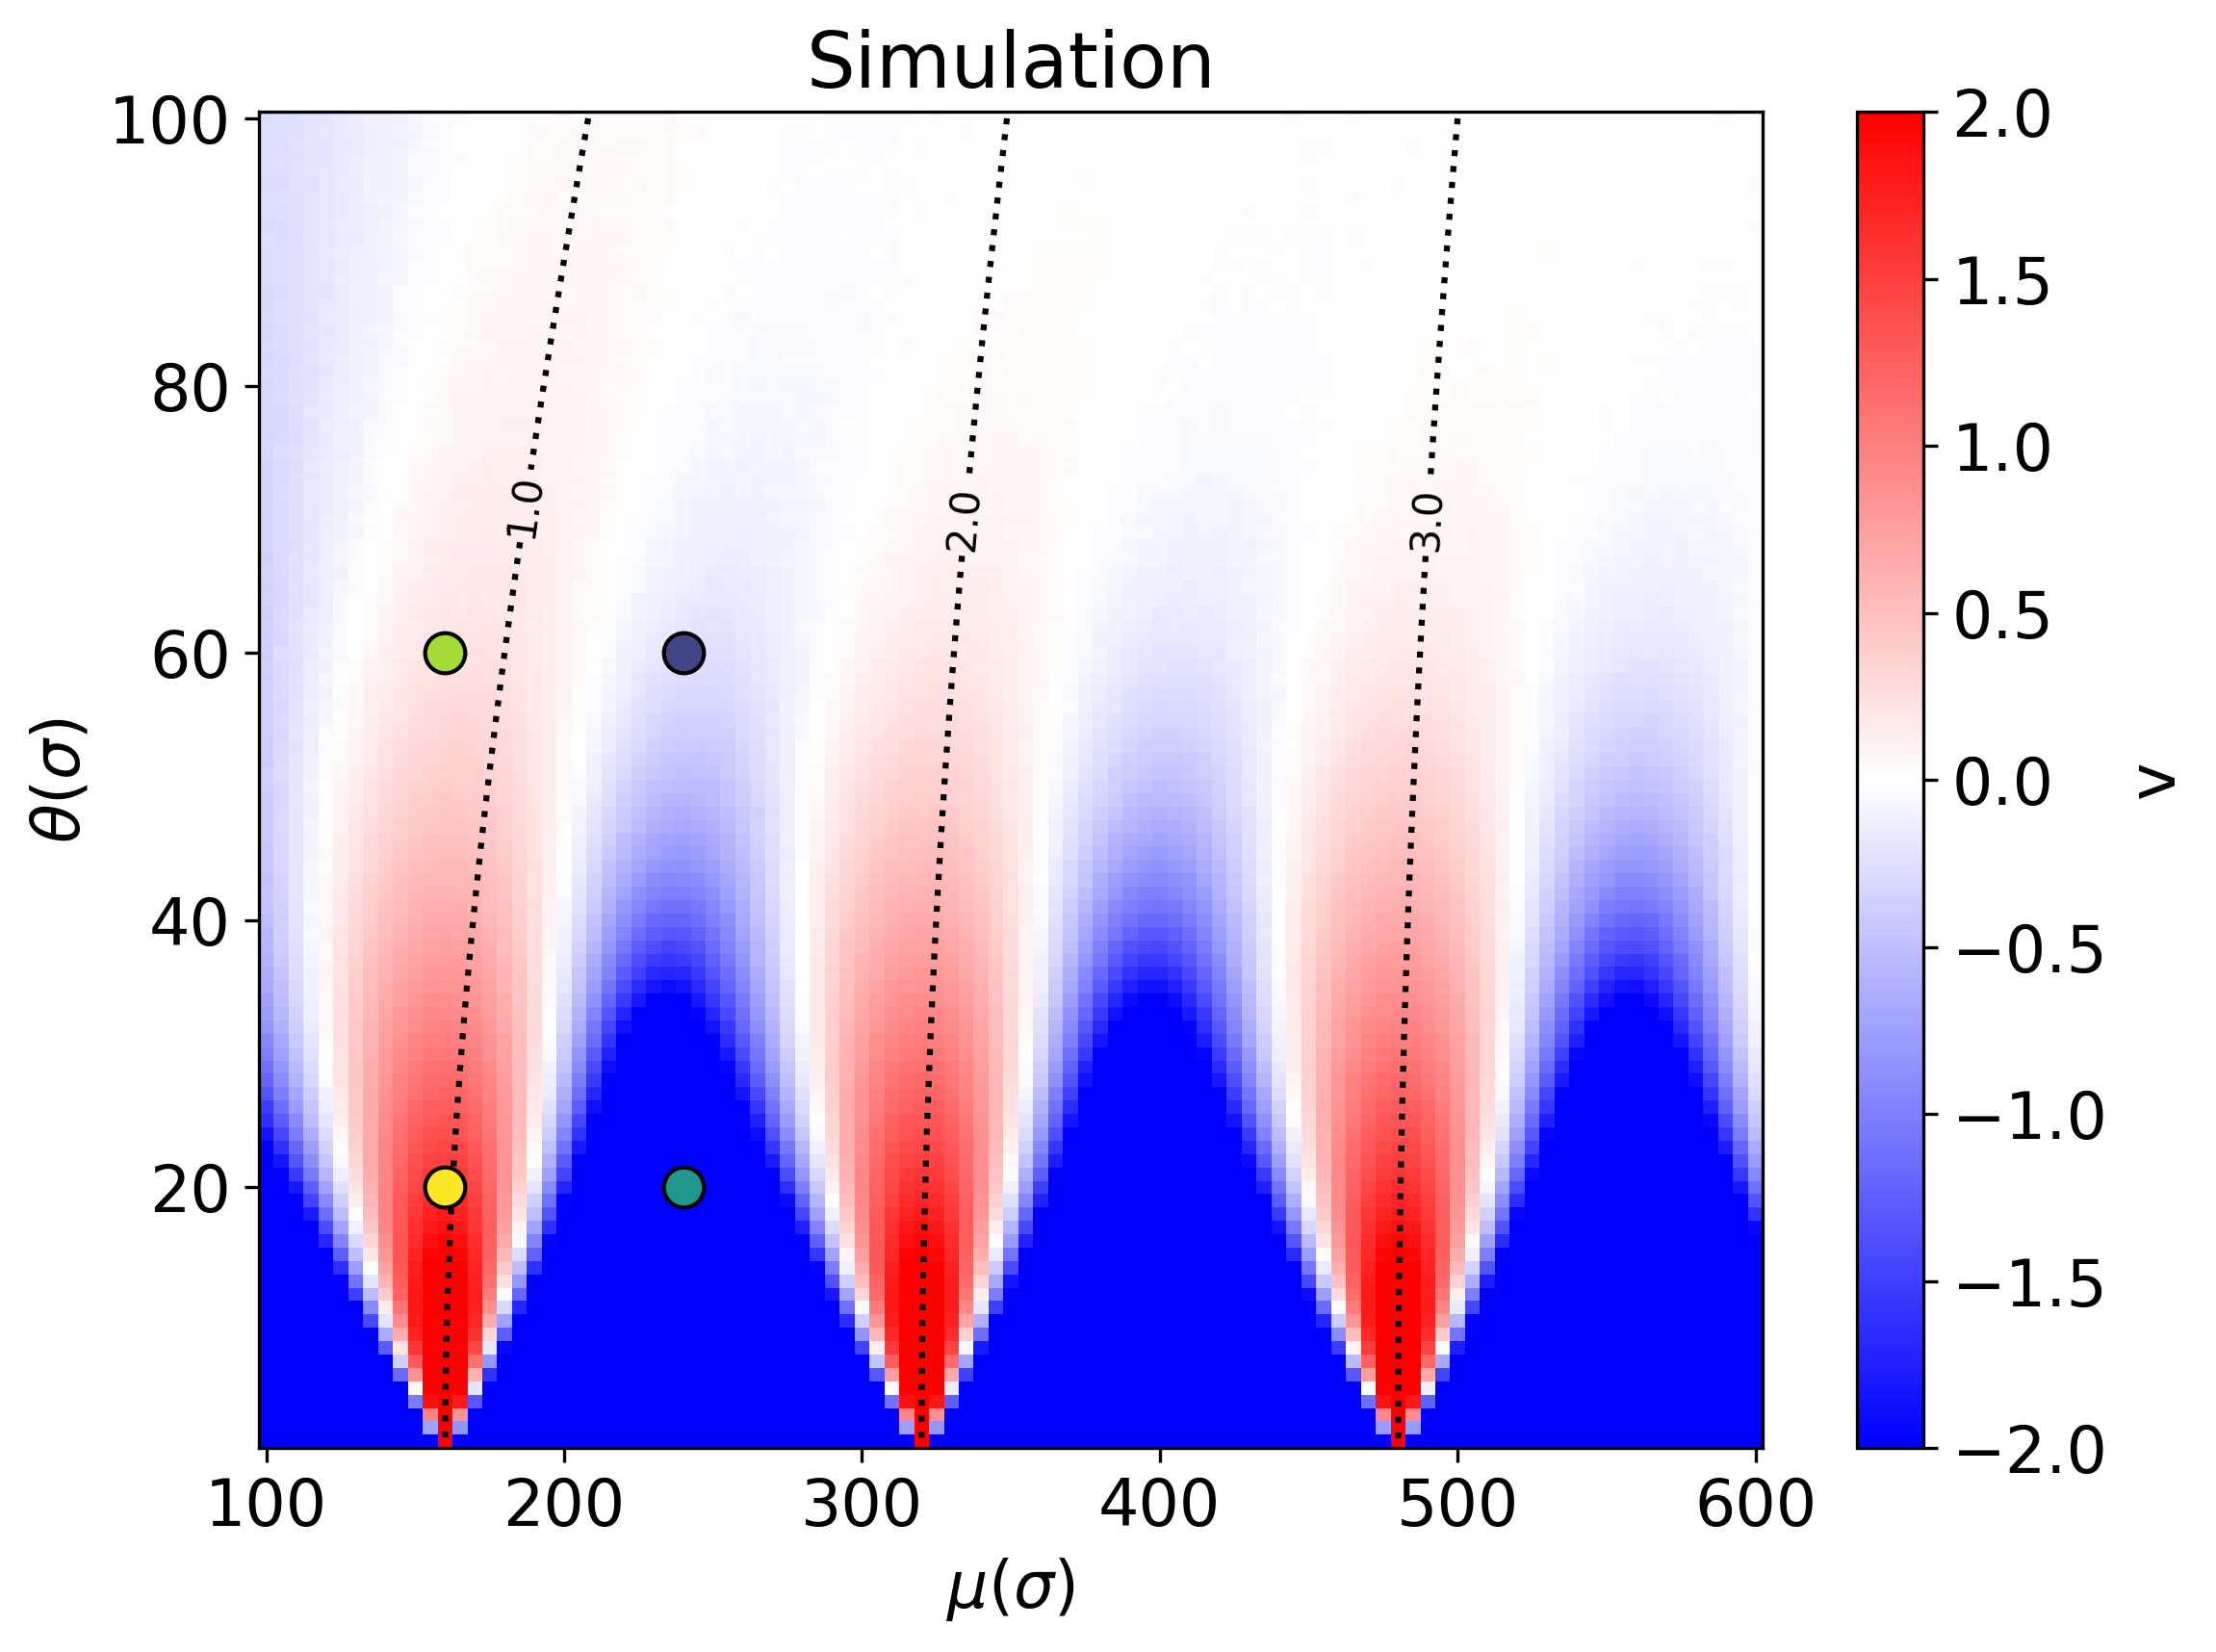

In [ ]:
from pathlib import Path
from nucleo.io.reading import reading_heatmap_one_config
from nucleo.io.plots import plot_single_heatmap
from matplotlib import pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 16



# Définition du root et de la configuration
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "2025-01-01_PSMN"
config_to_plot = {
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "alpha_choice": "periodic"
}

# Lecture des données
df_main, config_data = reading_heatmap_one_config(config_to_plot, "heatmap_th", root)

# Plot
fig, ax = plt.subplots(figsize=(8,6), dpi=300)
plot_single_heatmap(
    ax=ax,
    mu_values=config_data["mu_values"],
    theta_values=config_data["theta_values"],
    data=config_data["v_mean"],
    speed_col="v_mean",
    config=config_data["config"],
    plot_log2=True,
    vmin=-2,
    vmax=2,
    title_bar="v"
)


color_list= [
    (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0)), 
    (np.float64(0.647257), np.float64(0.8584), np.float64(0.209861), np.float64(1.0)), 
    (np.float64(0.120565), np.float64(0.596422), np.float64(0.543611), np.float64(1.0)), 
    (np.float64(0.253935), np.float64(0.265254), np.float64(0.529983), np.float64(1.0))
]

mus = np.array([160, 240])
thetas = np.array([20, 60])
points = [(160, 20), (160, 60), (240, 20), (240, 60)]

for i, (mu_pt, theta_pt) in enumerate(points):
    ax.scatter(
        mu_pt,
        theta_pt,
        color=color_list[i],
        s=100,          # taille du point
        edgecolor="black",  # contour du point
        zorder=10       # pour être au-dessus de la heatmap
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_187048/1727763490.py:23: RuntimeWarning: divide by zero encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/tmp/ipykernel_187048/1727763490.py:23: RuntimeWarning: invalid value encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


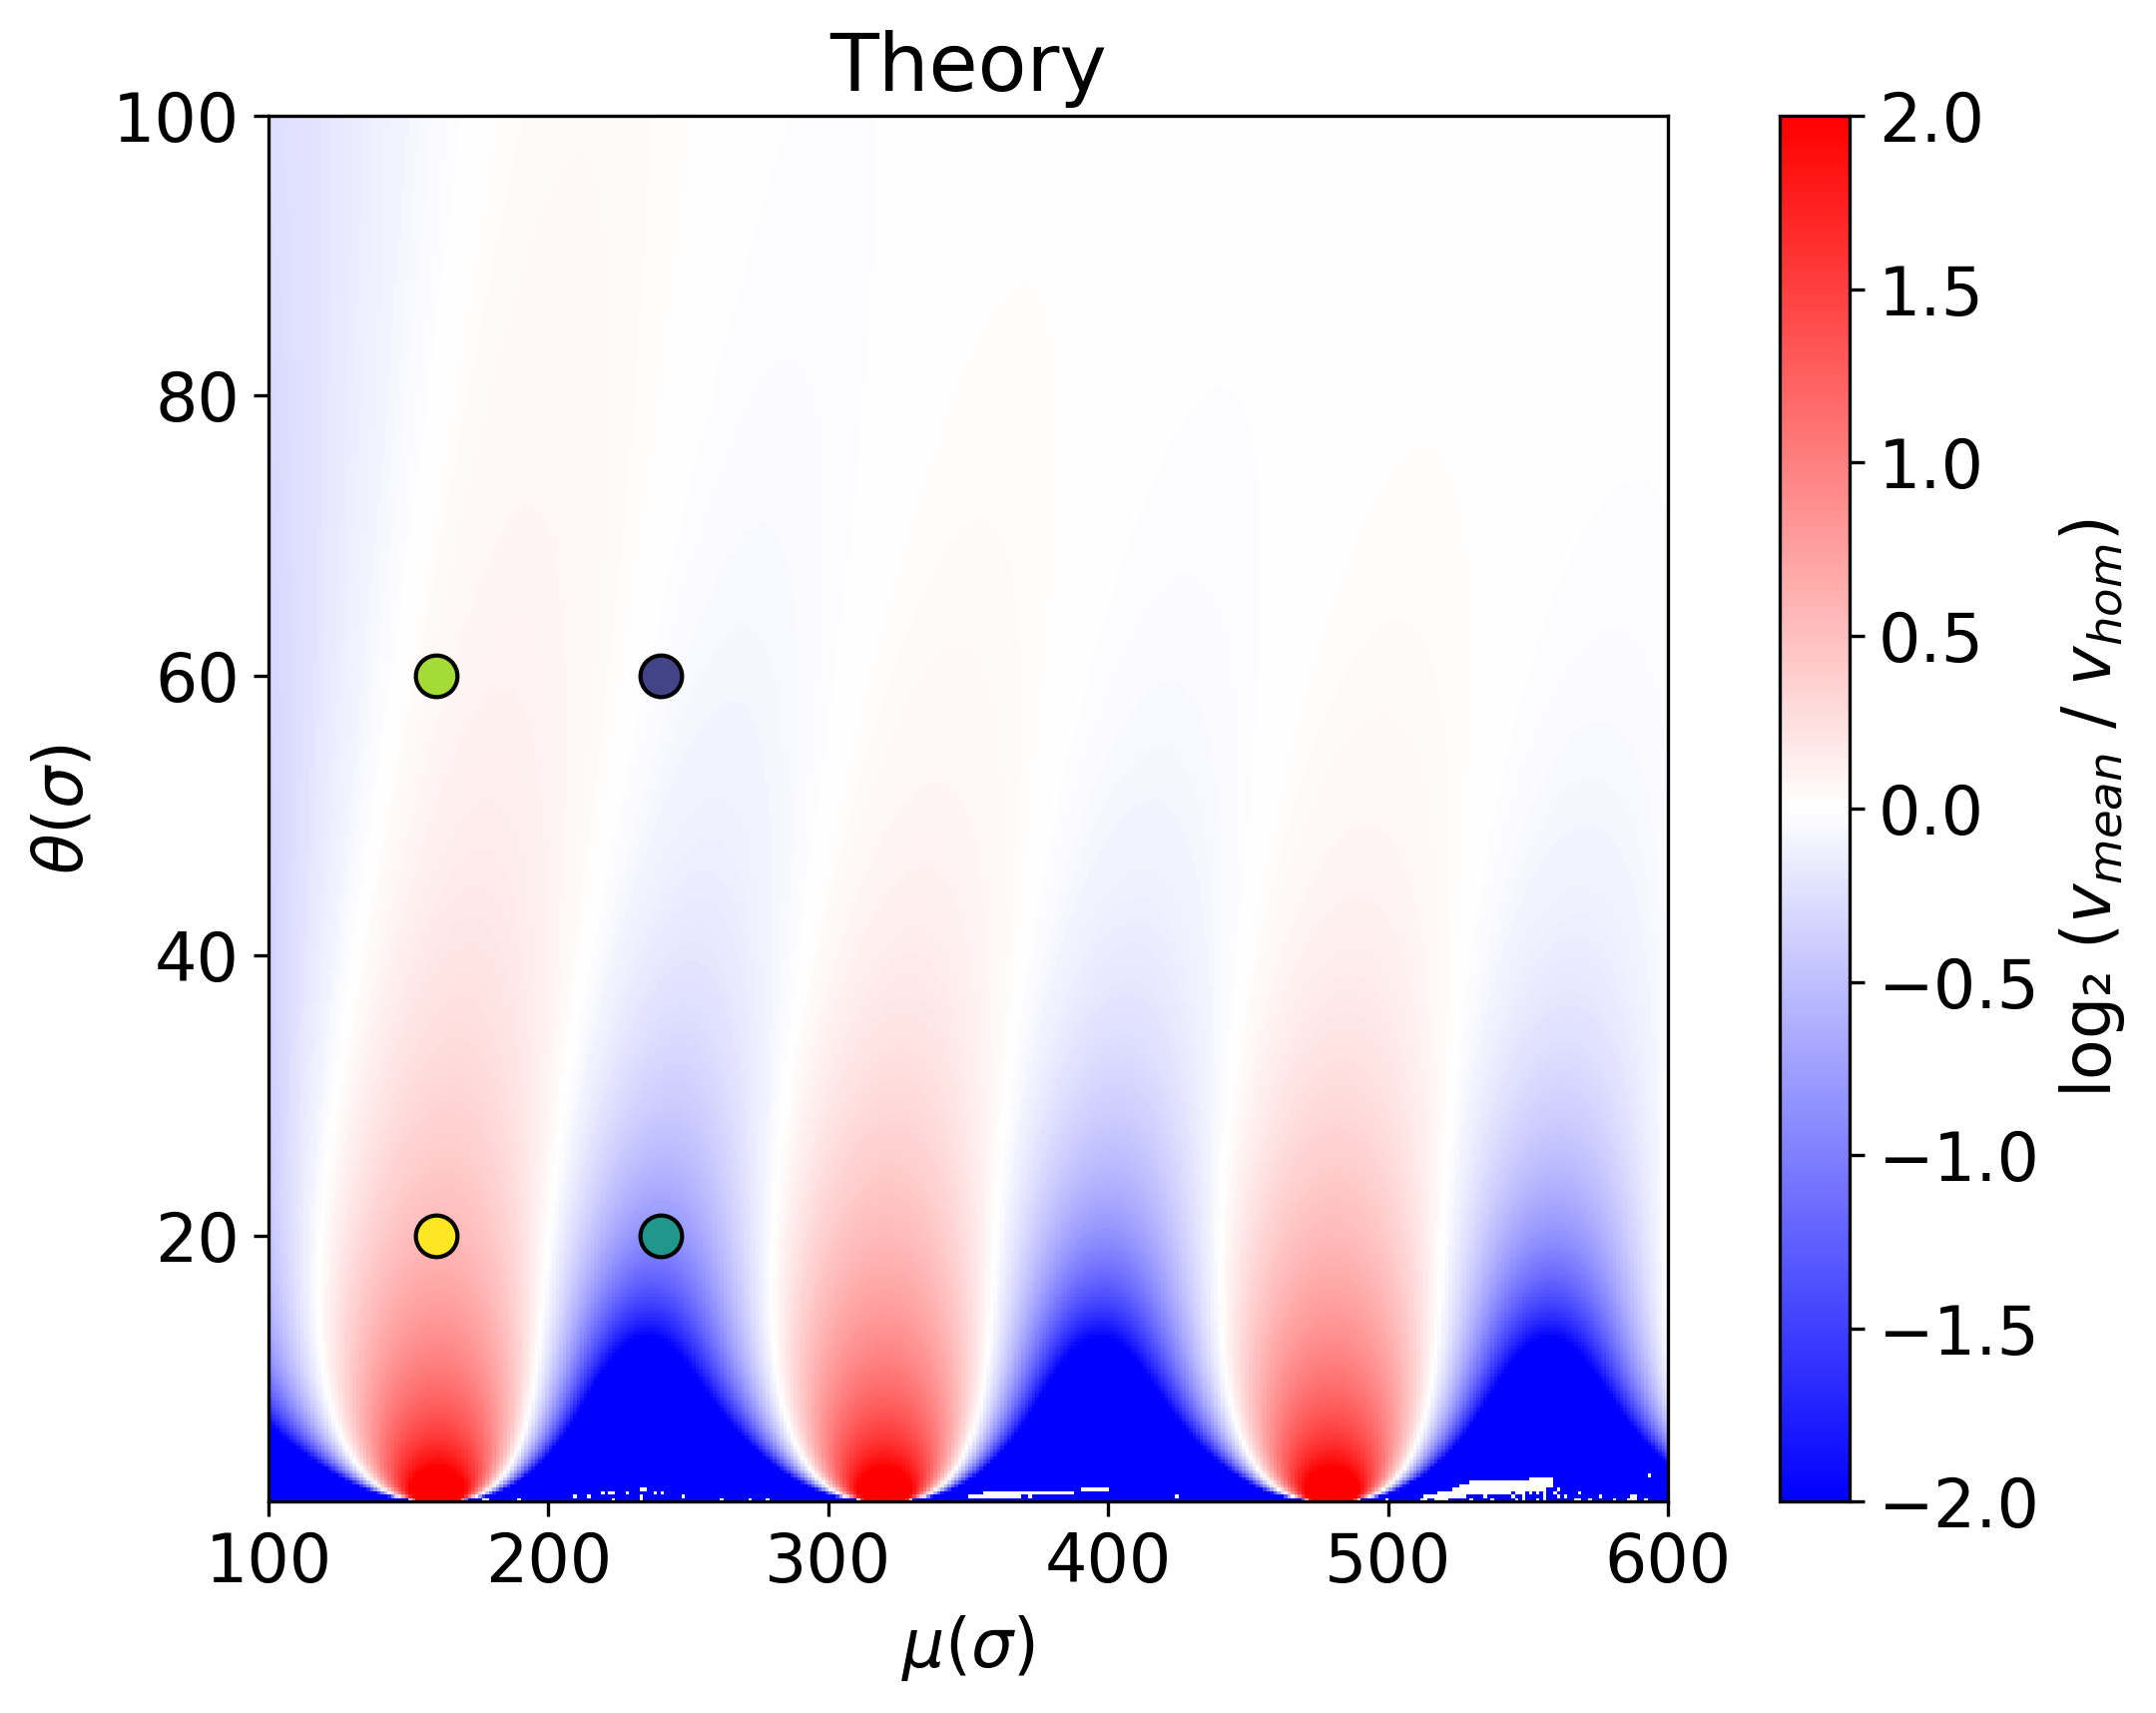

In [7]:
# Data from theory by Cesar
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16

root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/THEORY/")
with open(root / "cesar_data.pkl", "rb") as f:
    data = pickle.load(f)

mu_vals = data["mu_vals"]
theta_vals = data["sigma_vals"]
v_theo = data["v_theo"]

alphaf, alphao = 1, 0
l, s = 10, 150

accessibility = (alphao * s + alphaf * l) / (s + l)
v_flat = mu_vals * accessibility

data_plot = np.log2(v_theo / v_flat)
data_plot = np.nan_to_num(data_plot, nan=0.0)

vmin, vmax = -2, 2
title_bar = r"log₂ ($v_{mean}$ / $v_{hom}$)"

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

im = ax.imshow(
    data_plot,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="bwr",
    extent=[mu_vals.min(), mu_vals.max(), theta_vals.min(), theta_vals.max()],
)

ax.set_title("Theory")
ax.set_xlabel(r"$\mu(\sigma)$")
ax.set_ylabel(r"$\theta(\sigma)$")

ax.set_aspect(data_plot.shape[1] / data_plot.shape[0] * 5)

# Points (si définis)
for i, (mu_pt, theta_pt) in enumerate(points):
    ax.scatter(
        mu_pt,
        theta_pt,
        color=color_list[i],
        s=100,
        edgecolor="black",
        zorder=10,
    )

plt.tight_layout()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(title_bar)

plt.show()